# Background RMS Estimation

## 1. Load Data

The `DataBrowser` class allows us to query and filter our synced data. Here we'll explore the available keys and their values to understand what data we have access to.


Let's filter our data to find specific images. We'll search for:
- **Target**: T00528
- **Filter**: m600-band
- **Pattern**: Files ending with `*100.fits`


In [20]:
from ezphot.utils import DataBrowser
dbrowser = DataBrowser('scidata')
dbrowser.objname = 'T00528'
dbrowser.filter = 'm600'
target_imgset = dbrowser.search('*100.fits', return_type = 'science')
target_imglist = target_imgset.target_images

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*100.fits'


Loading Science Images: 100%|██████████| 90/90 [00:00<00:00, 139.51it/s]


You can also maks target_imglist from `List of path`

In [21]:
import glob
from ezphot.imageobjects import ScienceImage

target_pathlist = glob.glob('/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/*/m600/*100.fits')
target_imglist = [ScienceImage(path) for path in target_pathlist]

<br><br>
<br><br>

## 2. Background RMS Estimation

Background RMS (Root Mean Square) estimation is crucial for accurate photometry and image analysis, providing the noise characteristics of the background.

- **Estimate background RMS** using the SEP (Source Extractor Python) algorithm
- **Apply source masking** to improve background RMS estimation
- **Quantify background noise** for proper error analysis in photometry

> **Science Note**: Background RMS estimation quantifies the noise level in your images, which is essential for calculating photometric uncertainties and determining detection limits. This differs from simple background estimation by focusing on the statistical properties of the background noise.
<br><br>

### 2.1. Basic Background RMS Estimation

In [22]:
target_img = target_imglist[0]

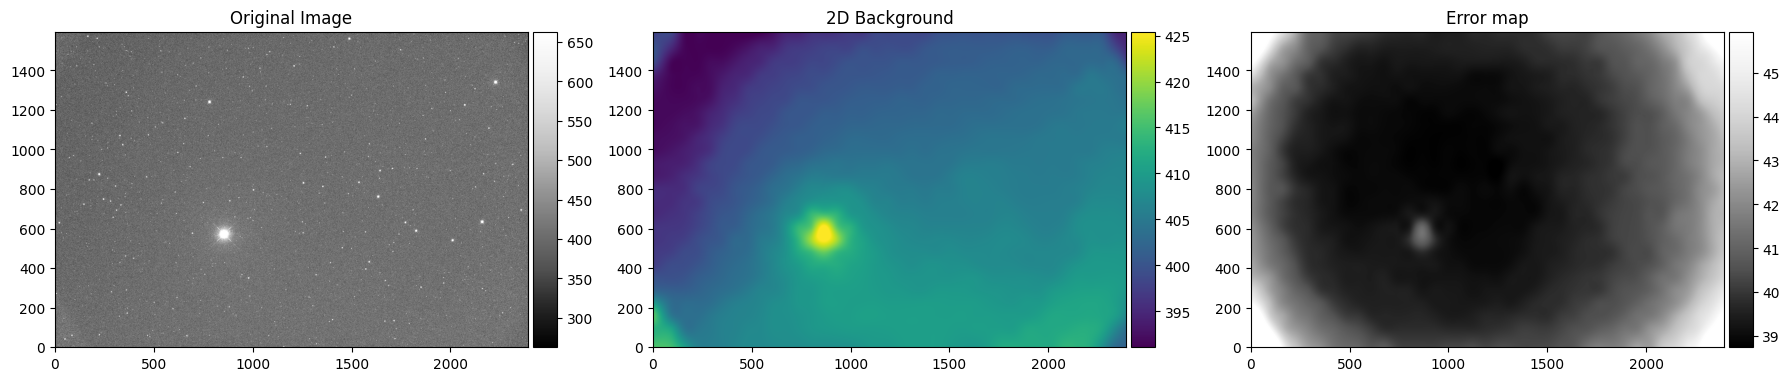

Cleared data and header from memory.


In [23]:
# Calculate the background map
target_bkgrms = target_img.calculate_bkgrms(
    target_srcmask = None,
    target_ivpmask = None,
    box_size = 256,
    filter_size = 3,
    save = False,
    verbose = True,
    visualize = True
)
# Clear the memory
target_bkgrms.clear(verbose = True)

<br><br>

### 2.2. Background RMS Estimation with source masking

Sometimes the background RMS model may include real sources like saturated stars or extended objects. In such cases, you can apply source masks to improve the background RMS estimation and obtain more accurate noise measurements.

> **💡 Pro Tip**: Source masking helps create cleaner background models by excluding bright objects that could bias the background RMS calculation, leading to more reliable noise estimates for photometric analysis.


#### 2.2.1. Automatic Source Mask Generation 

Masking source... [sigma = 5.0, mask_radius_factor = 2]
2948 non-saturated, 13 saturated sources
2961 sources masked.


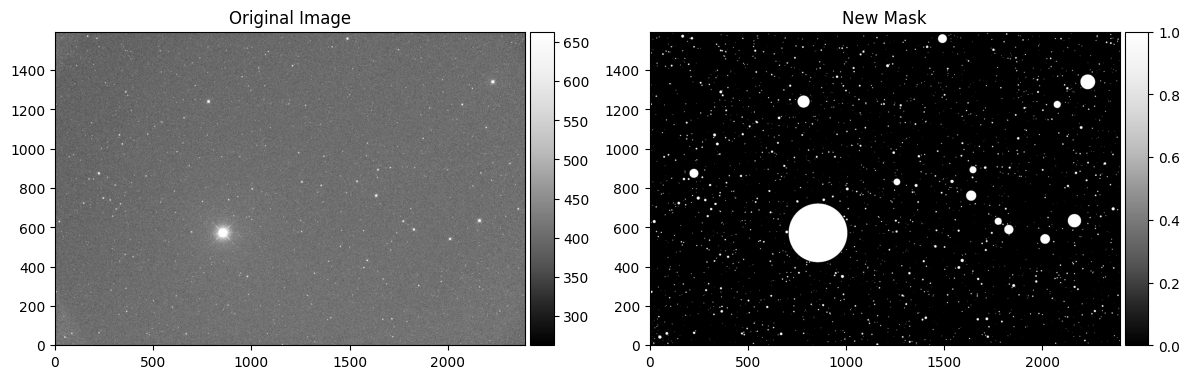

Iteration 1
External mask is loaded.
Masking source... [sigma = 5.0, mask_radius_factor = 2]
119 non-saturated, 0 saturated sources
119 sources masked.


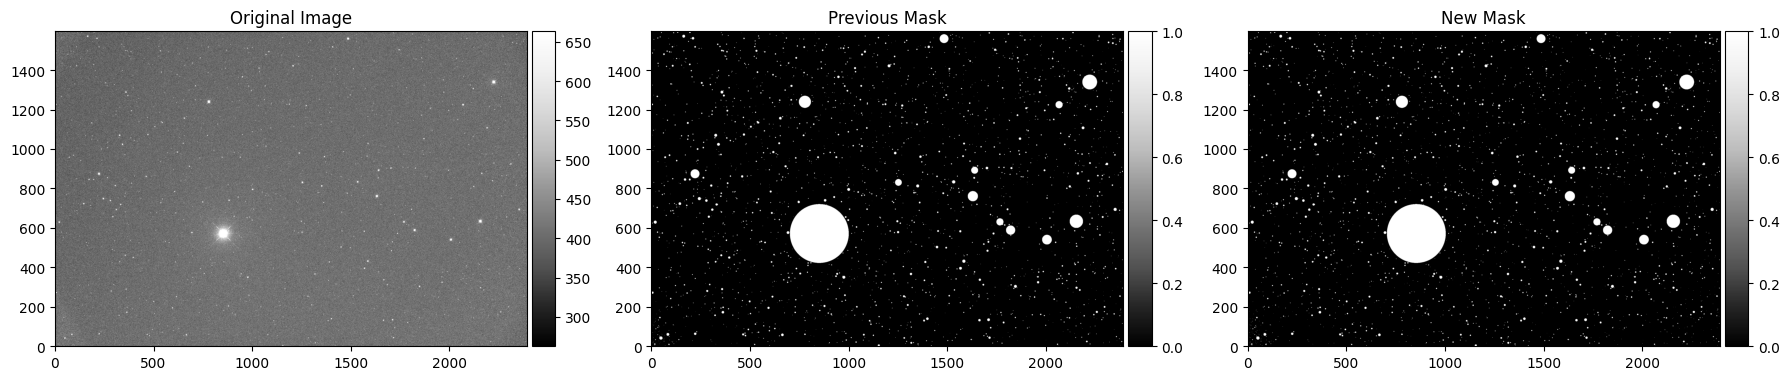

Iteration 2
External mask is loaded.
Masking source... [sigma = 5.0, mask_radius_factor = 2]
No sources detected to mask.


In [24]:
target_srcmask = target_img.calculate_sourcemask(
    target_srcmask = None,
    sigma = 5.0,
    mask_radius_factor = 2,
    saturation_level = 50000,
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False
)
# You can also iteratively apply source masking to the existing source mask,
for i in range(2):
    print('Iteration', i+1)
    target_srcmask = target_img.calculate_sourcemask(
        target_srcmask = target_srcmask,
        sigma = 5.0,
        mask_radius_factor = 2,
        saturation_level = 50000,
    )


#### 2.2.2. Manual Mask Generation

Added circular mask at (325.37, -77.39) with radius 300arcsec


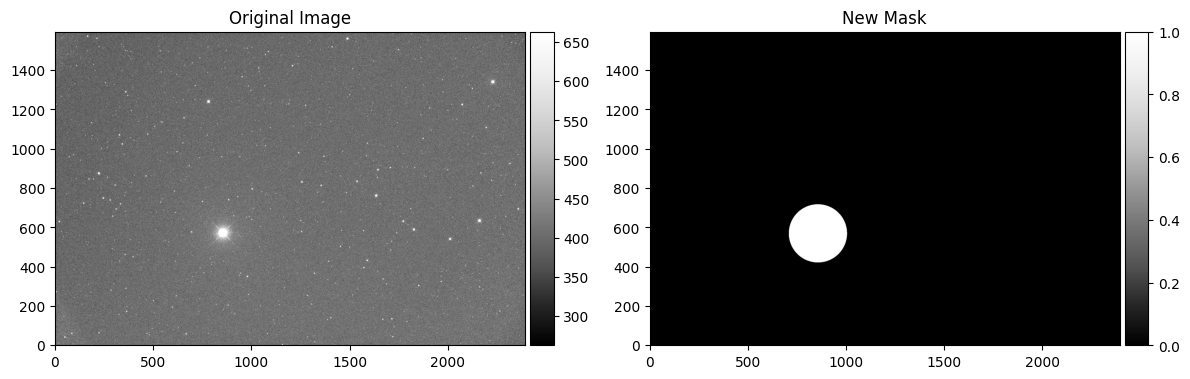

In [25]:
# If you wish to add manual source mask to reject the extended sources when background modeling,
target_srcmask = target_img.calculate_circularmask(
    target_srcmask = None,
    x_position = 325.37,
    y_position = -77.393,
    radius_arcsec = 300,
    unit = 'coord',
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False)

External mask is loaded.
Added circular mask at (325.07, -77.09) with radius 100arcsec


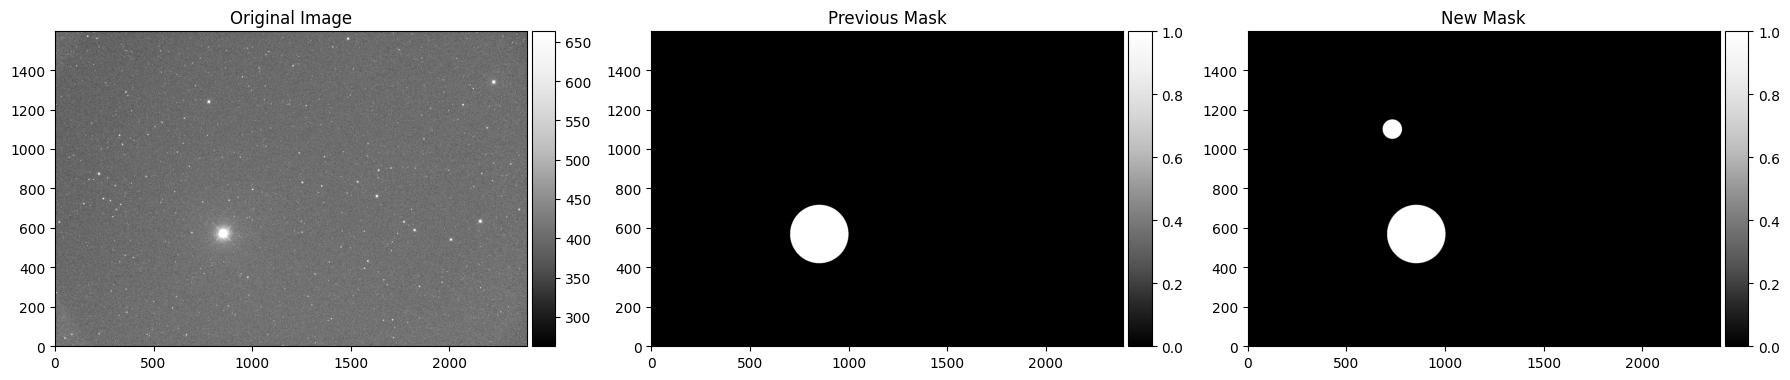

In [26]:
# Or If you wish to add manual source mask to the existing source mask,
target_srcmask = target_img.calculate_circularmask(
    target_srcmask = target_srcmask,
    x_position = 325.07,
    y_position = -77.093,
    radius_arcsec = 100,
    unit = 'coord',
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False)

#### 2.2.3. Re-generation of Background RMS Map with Source Mask


External mask is loaded.


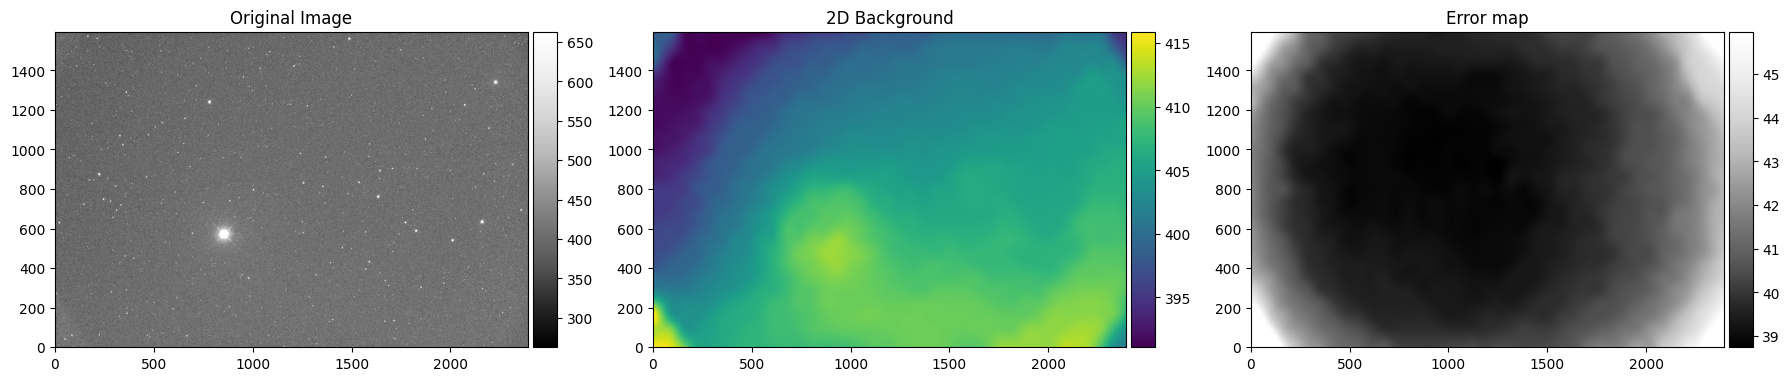

Cleared data and header from memory.


In [27]:
target_bkgrms_with_srcmask = target_img.calculate_bkgrms(
    target_srcmask = target_srcmask,
    target_ivpmask = None,
    box_size = 256,
    filter_size = 3,
    save = False,
    verbose = True,
    visualize = True
)
# Clear the memory
target_bkgrms_with_srcmask.clear(verbose = True)

<br><br>

### 2.3. Background RMS Estimation with Error Propagation

For the most accurate background RMS estimation (especially noise from hot pixels), it's essential to account for the error propagation from calibration frames (bias, dark, and flat fields). This approach provides a more realistic estimate of the background noise by considering the uncertainties introduced during the calibration process.

- **Propagate calibration errors** from master bias, dark, and flat frames
- **Account for read noise** and other instrumental effects
- **Provide realistic noise estimates** for photometric analysis

> **💡 Pro Tip**: Error propagation ensures that your background RMS estimates include all sources of noise, not just the statistical noise in the final image. This is crucial for accurate photometric uncertainty calculations and detection limit estimates.


#### 2.3.1. Loading the Master Calibration Frames

In [28]:
from ezphot.methods import Preprocess
preprocess = Preprocess()
preprocess.help()

Help for Preprocess

Public methods:
- correct_bd(target_img: ezphot.imageobjects.scienceimage.ScienceImage, bias_image: ezphot.imageobjects.calibrationimage.CalibrationImage, dark_image: ezphot.imageobjects.calibrationimage.CalibrationImage, save: bool = False, verbose: bool = True, **kwargs)
- correct_bdf(target_img: ezphot.imageobjects.scienceimage.ScienceImage, bias_image: ezphot.imageobjects.calibrationimage.CalibrationImage, dark_image: ezphot.imageobjects.calibrationimage.CalibrationImage, flat_image: ezphot.imageobjects.calibrationimage.CalibrationImage, save: bool = False, verbose: bool = True, **kwargs)
- correct_bias(target_img: ezphot.imageobjects.scienceimage.ScienceImage, bias_image: ezphot.imageobjects.calibrationimage.CalibrationImage, save: bool = False, verbose: bool = True, **kwargs)
- correct_dark(target_img: ezphot.imageobjects.scienceimage.ScienceImage, dark_image: ezphot.imageobjects.calibrationimage.CalibrationImage, save: bool = False, verbose: bool = True, **k

In [29]:
mbias = preprocess.get_masterframe_from_image(
    target_img = target_img,
    imagetyp = 'BIAS',
    max_days = 60
)[0]
mdark = preprocess.get_masterframe_from_image(
    target_img = target_img,
    imagetyp = 'DARK',
    max_days = 60
)[0]
mflat = preprocess.get_masterframe_from_image(
    target_img = target_img,
    imagetyp = 'FLAT',
    max_days = 60
)[0]

#### 2.3.2. Background RMS Calculation with Error Propagation

Now we can calculate the background RMS while properly propagating errors from the calibration frames. This method uses the master calibration frames to account for all sources of noise in the final background RMS estimate.


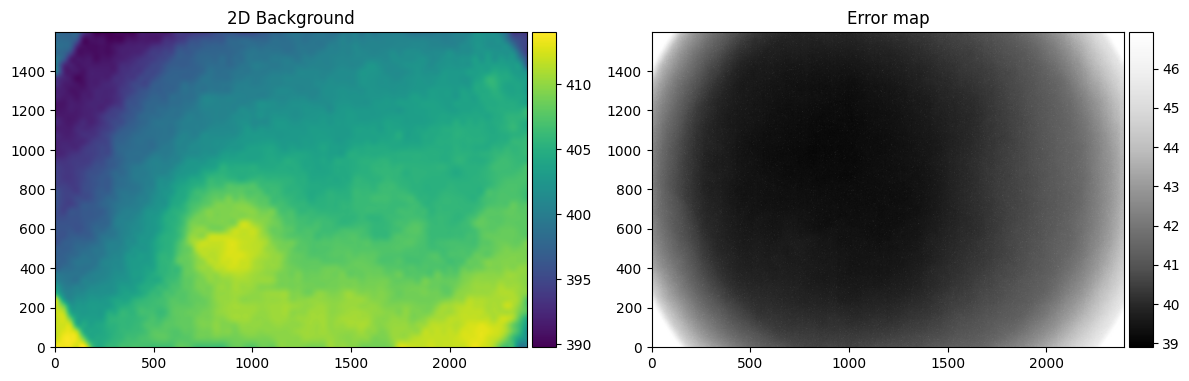

In [30]:
target_bkgrms_with_propagation = target_img.calculate_bkgrms_from_propagation(
    target_bkg = target_img.bkgmap, # To load the background map from the image, you need to run target_img.calculate_bkg(save = True) first.
    mbias = mbias,
    mdark = mdark,
    mflat = mflat,
    mflaterr = None,
    save = False,
    verbose = True,
    visualize = True
)

In [31]:
# Run for all target_imglist with multiprocessing
from multiprocessing import Pool
from tqdm import tqdm

def calculate_bkgrms(target_img):    
    mbias = preprocess.get_masterframe_from_image(
        target_img = target_img,
        imagetyp = 'BIAS',
        max_days = 60
    )[0]
    mdark = preprocess.get_masterframe_from_image(
        target_img = target_img,
        imagetyp = 'DARK',
        max_days = 60
    )[0]
    mflat = preprocess.get_masterframe_from_image(
        target_img = target_img,
        imagetyp = 'FLAT',
        max_days = 60
    )[0]
    target_bkgrms_with_propagation = target_img.calculate_bkgrms_from_propagation(
        target_bkg = target_img.bkgmap, # To load the background map from the image, you need to run target_img.calculate_bkg(save = True) first.
        mbias = mbias,
        mdark = mdark,
        mflat = mflat,
        mflaterr = None,
        save = True,
        verbose = False,
        visualize = False
    )
                
    mbias.clear(verbose = False)
    mdark.clear(verbose = False)
    mflat.clear(verbose = False)
    target_bkgrms_with_propagation.clear(verbose = False)
    
with Pool(processes = 16) as pool:
    # Use tqdm with imap to show progress
    list(tqdm(pool.imap(calculate_bkgrms, target_imglist), 
              total=len(target_imglist), 
              desc="Calculating background RMS with error propagation"))


Calculating background RMS with error propagation: 100%|██████████| 90/90 [02:07<00:00,  1.42s/it]


After calculation of background RMS with save option as "TRUE", you can access to the background RMS maps easily from different options (`DataBrowser`, `ImageSet`)

In [32]:
dbrowser = DataBrowser('scidata')
dbrowser.objname = 'T00528'
dbrowser.filter = 'm600'
target_imgset = dbrowser.search('*100.fits', return_type = 'science')
# From ImageSet
target_bkgrmslist = target_imgset.bkgrms
# From DataBrowser
target_bkgrmsset = dbrowser.search('*.bkgrms', return_type = 'errormap')
target_bkgrmslist = target_bkgrmsset.target_images

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*100.fits'


Loading bkgrms: 100%|██████████| 90/90 [00:00<00:00, 186.96it/s]


[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*.bkgrms'


Loading Errormaps: 100%|██████████| 90/90 [00:00<00:00, 516.20it/s]
